## 1. Import Library

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from scipy.stats import skew

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR


## 2. Load Data

In [60]:
df = pd.read_csv('cars_combined_final2.csv')

categorical_features = ['car_type', 'brand_name', 'model', 'engine_type', 'transmission', 'location']
numerical_features   = ['year', 'total_km']
TARGET_COL           = 'price'

print(f'Shape data: {df.shape}')
df.head()


Shape data: (3668, 9)


,car_type,brand_name,model,price,year,total_km,location,engine_type,transmission
0,MPV,Suzuki,Ertiga,120000000,2016,127000.0,Bekasi,Bensin,Manual
1,MPV,Toyota,Veloz,145000000,2016,120000.0,Unknown,Bensin,Otomatis
2,MPV,Daihatsu,Xenia,125000000,2015,69195.0,Pekanbaru,Bensin,Manual
3,MPV,Toyota,Avanza,88000000,2008,130699.0,Unknown,Bensin,Manual
4,MPV,Toyota,Avanza,125000000,2018,133215.0,Unknown,Bensin,Manual


## 3. Exploratory Data Analysis (EDA)

In [61]:
# Overview
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3668 entries, 0 to 3667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_type      3668 non-null   str    
 1   brand_name    3668 non-null   str    
 2   model         3668 non-null   str    
 3   price         3668 non-null   int64  
 4   year          3668 non-null   int64  
 5   total_km      3668 non-null   float64
 6   location      3668 non-null   str    
 7   engine_type   3668 non-null   str    
 8   transmission  3668 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 258.0 KB


In [62]:
print(df['brand_name'].value_counts())


brand_name
Toyota           1371
Honda             824
Daihatsu          356
Suzuki            246
Nissan            215
Mercedes Benz     187
Mitsubishi        172
BMW               154
Mazda             111
Hyundai            32
Name: count, dtype: int64


In [63]:
print(df['location'].value_counts())


location
Jakarta Pusat        964
Unknown              759
Surabaya             267
Tangerang Selatan    213
Jakarta Selatan      136
Bandung              124
Jakarta Utara        119
Bekasi               118
Denpasar              94
Bogor                 79
Tangerang             76
Jakarta Barat         76
Yogyakarta            74
Jakarta Timur         74
Semarang              65
Pekanbaru             62
Depok                 62
Sidoarjo              58
Malang                49
Medan                 48
Jember                38
Serang                21
Palembang             19
Tegal                 17
Batam                 13
Karawang              11
Balikpapan             7
Makassar               7
Banjarmasin            7
Cirebon                6
Cimahi                 3
Gresik                 2
Name: count, dtype: int64


In [64]:
df.describe()


,price,year,total_km
count,3.668000e+03,3668.000000,3668.000000
mean,2.345890e+08,2015.430480,75291.726281
std,2.076099e+08,5.840188,53910.588845
min,3.500000e+07,1970.000000,1.000000
25%,1.250000e+08,2013.000000,35240.000000
50%,1.750000e+08,2016.000000,69000.000000
75%,2.630000e+08,2019.000000,101000.000000
max,3.300000e+09,2025.000000,500000.000000


In [65]:
print('=== Missing Values ===')
print(df.isnull().sum())


=== Missing Values ===
car_type        0
brand_name      0
model           0
price           0
year            0
total_km        0
location        0
engine_type     0
transmission    0
dtype: int64


In [66]:
pd.set_option('display.max_rows', None)
print(sorted(df['model'].unique()))
pd.reset_option('display.max_rows')


['2', '3 Series', '5 Series', '7 Series', 'A-Class', 'Accord', 'Agya', 'Alphard', 'Avanza', 'Avanza Veloz', 'Ayla', 'BRV', 'Baleno', 'Brio', 'C-Class', 'CR-V', 'CX-3', 'CX-5', 'Calya', 'Camry', 'City', 'Civic', 'Corolla', 'Creta', 'E-Class', 'Ertiga', 'Fortuner', 'Freed', 'GLC-Class', 'GranMax', 'Grand Livina', 'Grand Vitara', 'HRV', 'Harrier', 'Ignis', 'Jazz', 'Jimny', 'Juke', 'Karimun', 'Kijang', 'Kijang Innova', 'Land Cruiser', 'March', 'Mirage', 'Mobilio', 'Outlander Sport', 'Pajero Sport', 'Palisade', 'Raize', 'Rush', 'S-Class', 'SX4 S Cross', 'Santa Fe', 'Serena', 'Sienta', 'Sigra', 'Sirion', 'Splash', 'Swift', 'Teana', 'Terios', 'Vellfire', 'Veloz', 'Venturer', 'Vios', 'WR-V', 'X-Trail', 'X1', 'X3', 'X5', 'XL7', 'Xenia', 'Xpander', 'Yaris', 'Yaris Cross']


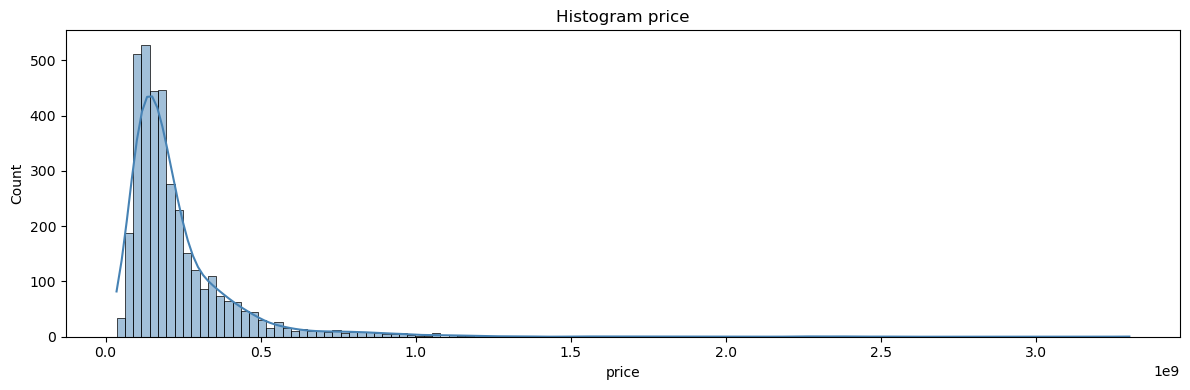

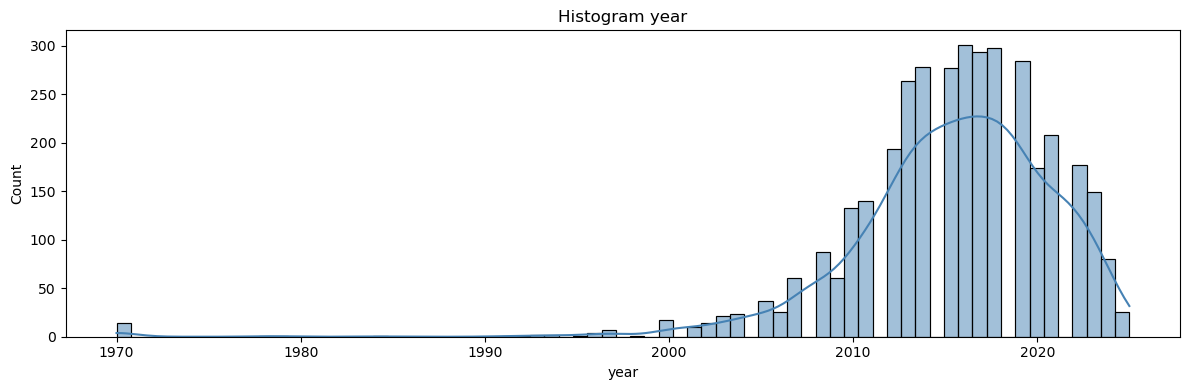

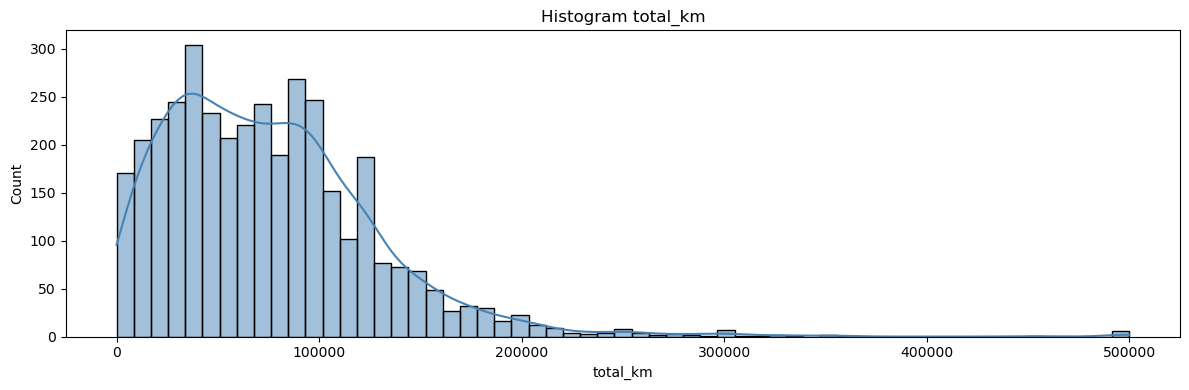

In [67]:
# Histogram — Numerikal
num_features_eda = [TARGET_COL] + numerical_features

for col in num_features_eda:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.histplot(df[col].dropna(), kde=True, color='steelblue', ax=ax)
    ax.set_title(f'Histogram {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


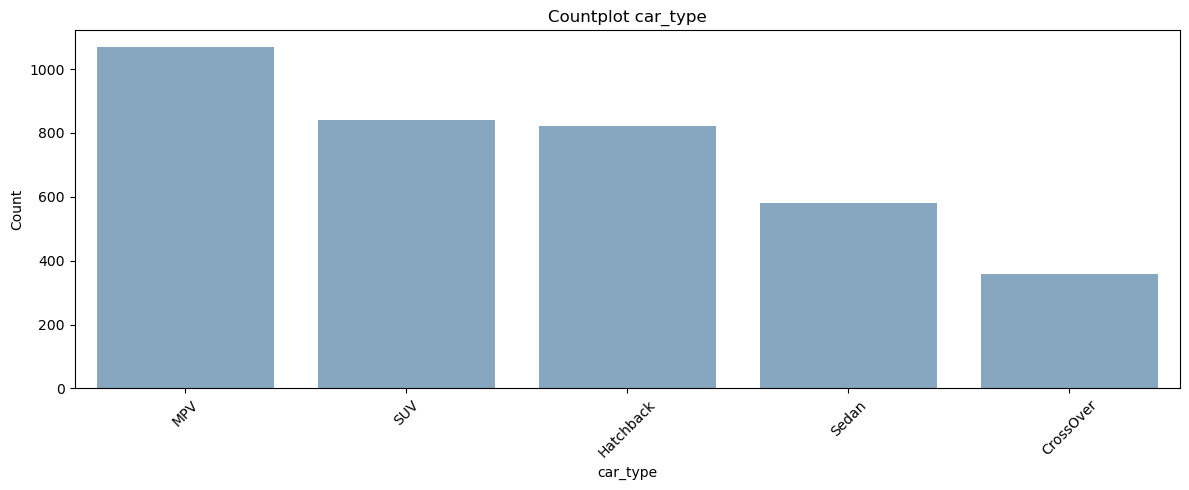

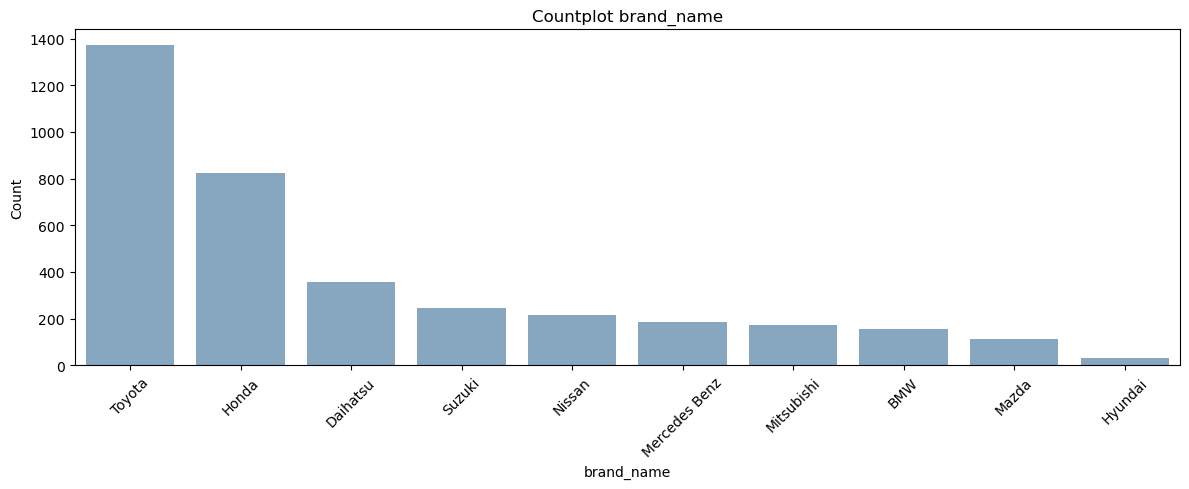

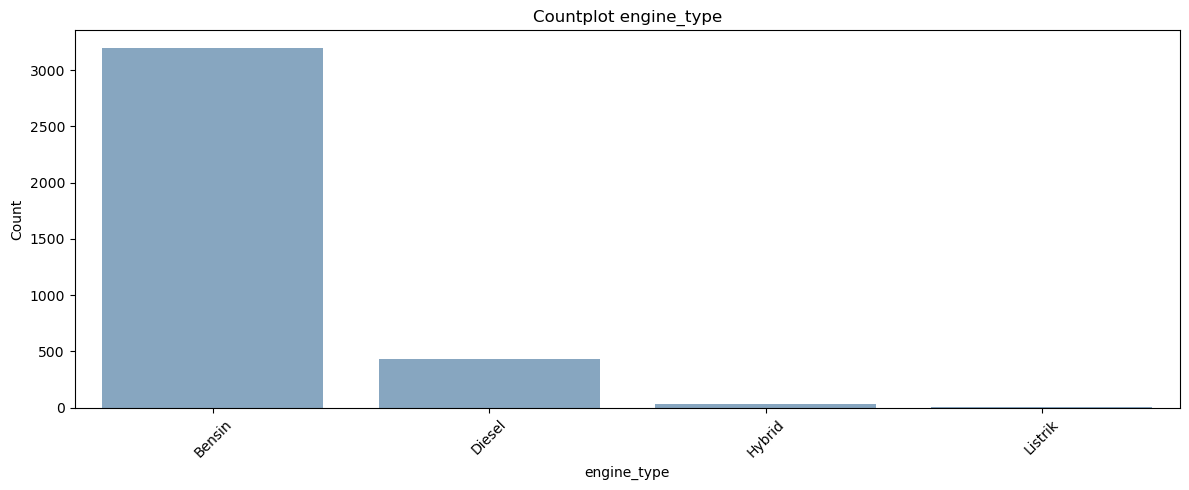

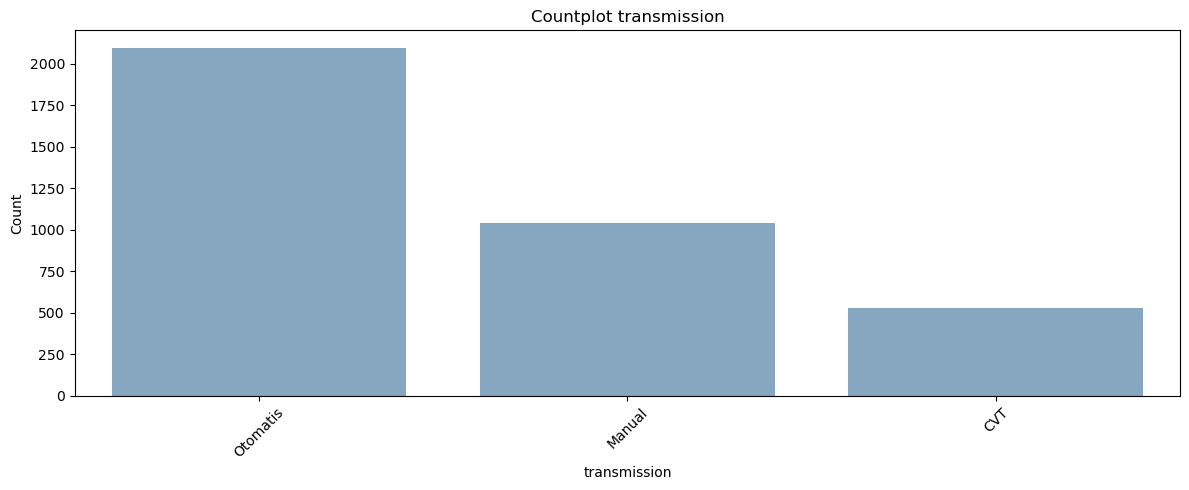

In [68]:
# Countplot — Kategorikal
countplot_cols = [c for c in categorical_features if c not in ['model', 'location']]

for col in countplot_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    order   = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color='steelblue', alpha=0.7, ax=ax)
    ax.set_title(f'Countplot {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


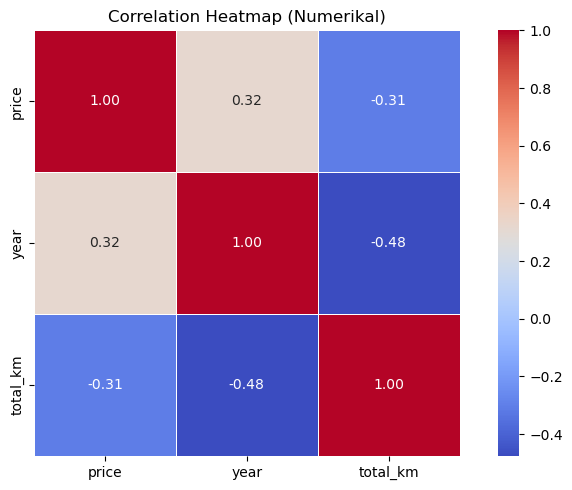

In [69]:
# Heatmap Korelasi
plt.figure(figsize=(8, 5))
corr = df[[TARGET_COL] + numerical_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerikal)')
plt.tight_layout()
plt.show()


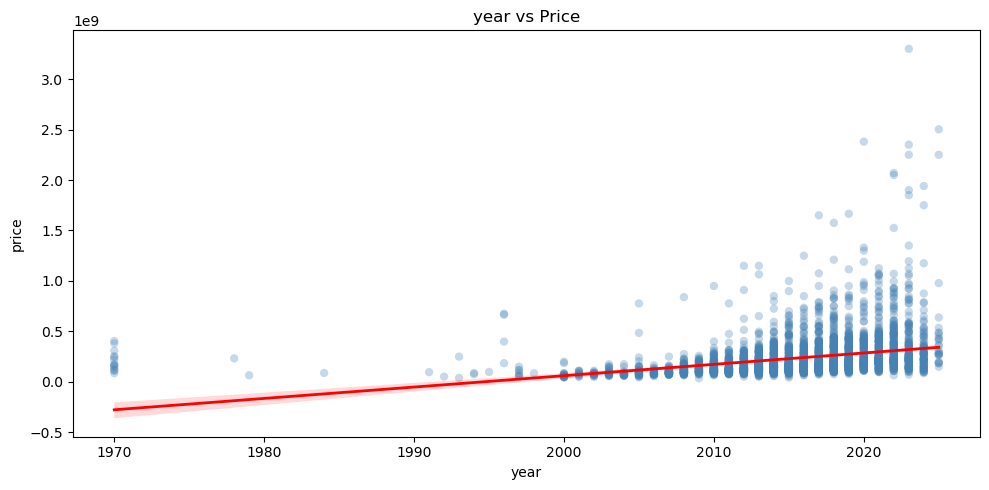

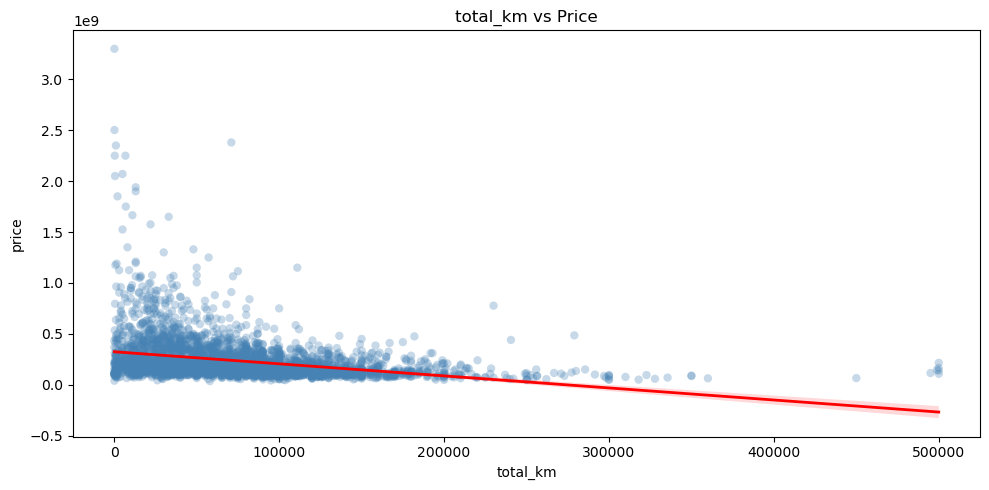

In [70]:
# Scatterplot — Numerikal vs Price
for col in numerical_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.regplot(
        data=df, x=col, y=TARGET_COL,
        scatter_kws={'alpha': 0.3, 'color': 'steelblue', 'edgecolors': 'none'},
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax
    )
    ax.set_title(f'{col} vs Price')
    plt.tight_layout()
    plt.show()


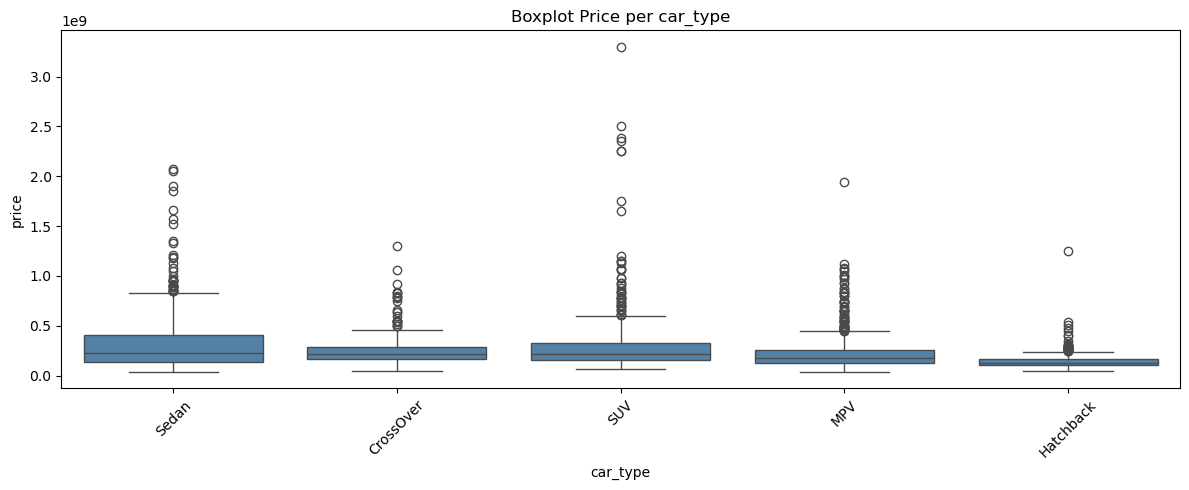

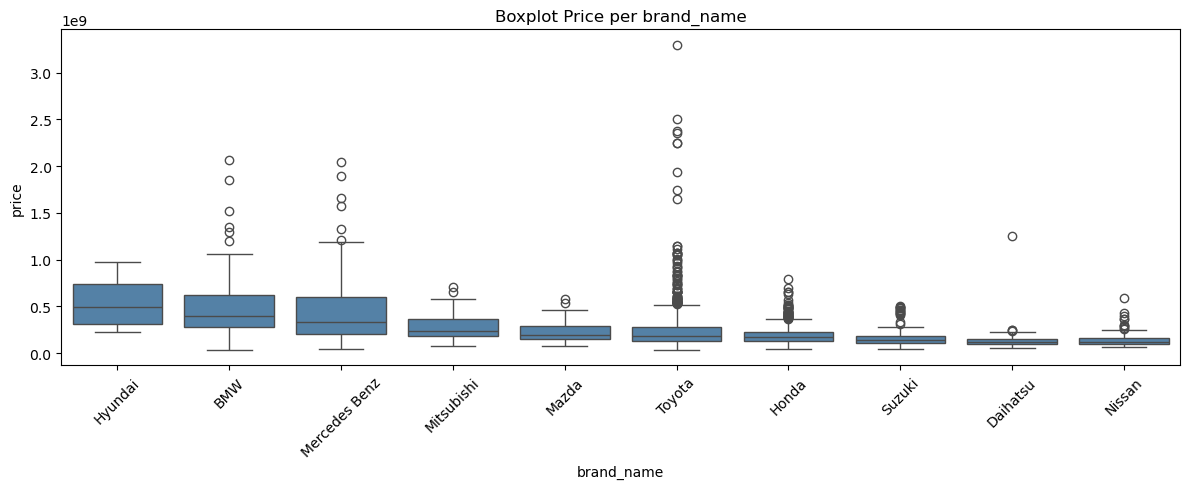

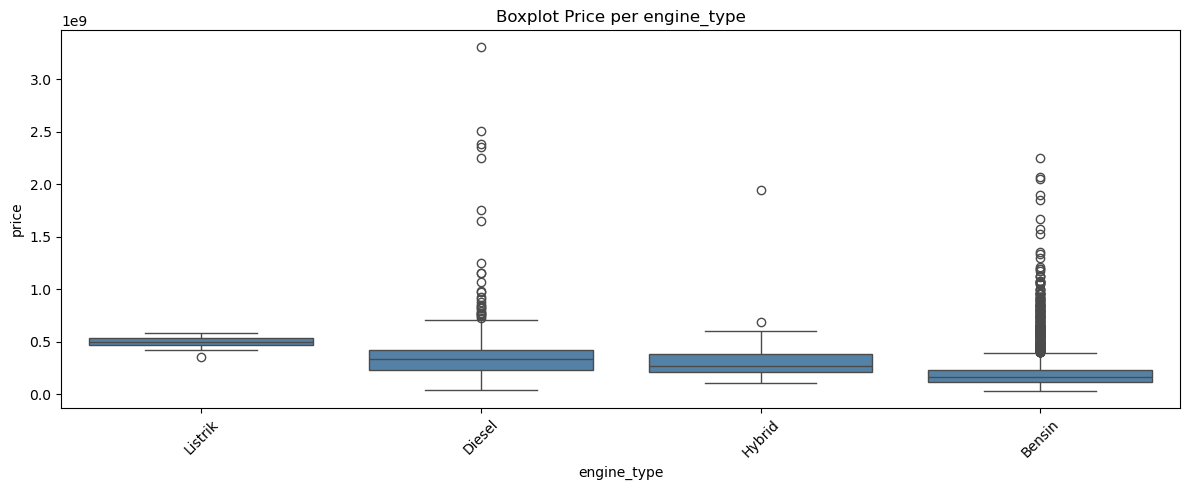

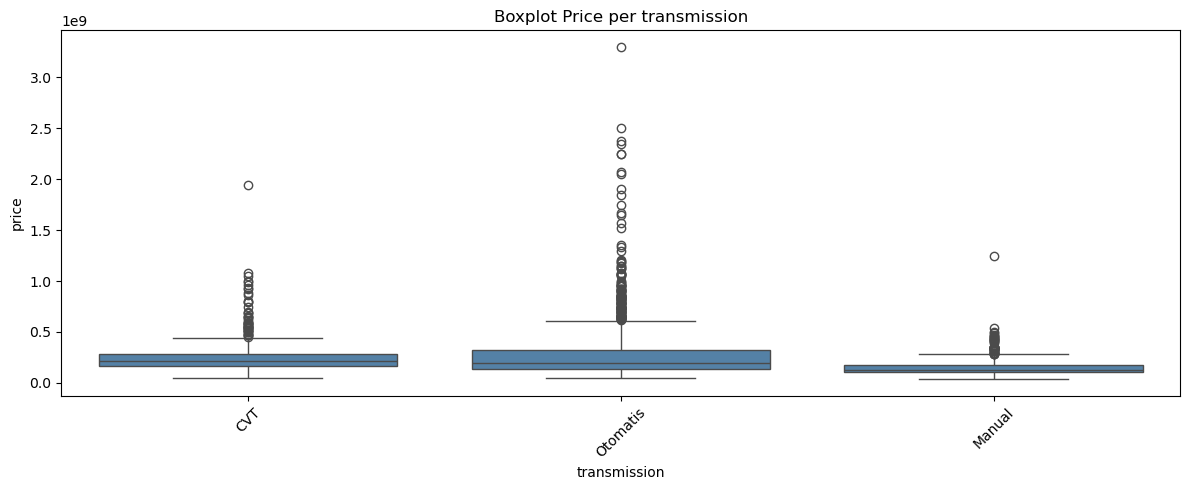

In [71]:
# Boxplot — Kategorikal vs Price 
boxplot_cols = [c for c in categorical_features if c not in ['model', 'location']]

for col in boxplot_cols:
    order  = df.groupby(col)[TARGET_COL].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x=col, y=TARGET_COL, order=order, color='steelblue', ax=ax)
    ax.set_title(f'Boxplot Price per {col}')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


## 4. Train-Test Split



In [72]:
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')


X_train : (2934, 8)
X_test  : (734, 8)
y_train : (2934,)
y_test  : (734,)


In [73]:
#Memisahkan kolom numerikal dan kategorikal
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerikal  : {num_cols}')
print(f'Kategorikal: {cat_cols}')


Numerikal  : ['year', 'total_km']
Kategorikal: ['car_type', 'brand_name', 'model', 'location', 'engine_type', 'transmission']


## 5. Encoding Kategorikal



In [74]:
# One Hot Encoding
encoding_name = 'OneHotEncoding'

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Samakan kolom train & test (antisipasi kategori tidak muncul di test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Simpan sebagai pickle
encoding_artifacts = {'method': 'ohe', 'cat_cols': cat_cols}

print(f'=== Preview setelah One Hot Encoding ===')
print(f'Jumlah kolom: {X_train_enc.shape[1]}')
X_train_enc.head()


=== Preview setelah One Hot Encoding ===
Jumlah kolom: 125


,year,total_km,car_type_Hatchback,car_type_MPV,car_type_SUV,car_type_Sedan,brand_name_Daihatsu,brand_name_Honda,brand_name_Hyundai,brand_name_Mazda,...,location_Tangerang,location_Tangerang Selatan,location_Tegal,location_Unknown,location_Yogyakarta,engine_type_Diesel,engine_type_Hybrid,engine_type_Listrik,transmission_Manual,transmission_Otomatis
1450,2014,88920.0,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2186,2014,94000.0,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
810,2013,119000.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3618,2016,125000.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
67,2023,17000.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
# Label Encoding

# encoding_name = 'LabelEncoding'
# label_encoders = {}
# X_train_enc = X_train.copy()
# X_test_enc  = X_test.copy()
#
# for col in cat_cols:
#     le = LabelEncoder()
#     X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
#     X_test_enc[col]  = X_test_enc[col].astype(str).apply(
#         lambda x: x if x in le.classes_ else le.classes_[0]
#     )
#     X_test_enc[col] = le.transform(X_test_enc[col])
#     label_encoders[col] = le
#
# encoding_artifacts = {'method': 'label', 'label_encoders': label_encoders, 'cat_cols': cat_cols}
# print(f'Jumlah kolom: {X_train_enc.shape[1]}')
# X_train_enc.head()


In [76]:
# Target Encoding 

# encoding_name = 'TargetEncoding'
# target_means  = {}
# overall_mean  = y_train.mean()
# X_train_enc   = X_train.copy()
# X_test_enc    = X_test.copy()
#
# for col in cat_cols:
#     means = X_train.join(y_train).groupby(col)[TARGET_COL].mean()
#     X_train_enc[col] = X_train_enc[col].map(means).fillna(overall_mean)
#     X_test_enc[col]  = X_test_enc[col].map(means).fillna(overall_mean)
#     target_means[col] = means
#
# encoding_artifacts = {'method': 'target', 'target_means': target_means,
#                        'overall_mean': overall_mean, 'cat_cols': cat_cols}
# print(f'Jumlah kolom: {X_train_enc.shape[1]}')
# X_train_enc.head()


## 6. Scaling Numerikal


In [77]:
# Standard Scaler
scaler = StandardScaler()
scaler_name = 'StandardScaler'

X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])  # fit + transform train
X_test_enc[num_cols]  = scaler.transform(X_test_enc[num_cols])       # transform saja test

print(f'=== Preview setelah {scaler_name} ===')
X_train_enc.head()


=== Preview setelah StandardScaler ===


,year,total_km,car_type_Hatchback,car_type_MPV,car_type_SUV,car_type_Sedan,brand_name_Daihatsu,brand_name_Honda,brand_name_Hyundai,brand_name_Mazda,...,location_Tangerang,location_Tangerang Selatan,location_Tegal,location_Unknown,location_Yogyakarta,engine_type_Diesel,engine_type_Hybrid,engine_type_Listrik,transmission_Manual,transmission_Otomatis
1450,-0.255106,0.249451,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2186,-0.255106,0.343683,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
810,-0.429496,0.807421,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3618,0.093674,0.918718,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
67,1.314404,-1.084630,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [78]:
# MinMax Scaler 

# scaler = MinMaxScaler()
# scaler_name = 'MinMaxScaler'
# X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
# X_test_enc[num_cols]  = scaler.transform(X_test_enc[num_cols])
# print(f'=== Preview setelah {scaler_name} ===')
# X_train_enc.head()


## 7. Modeling

In [79]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    mape = np.mean(np.abs((y_te - pred) / y_te)) * 100

    print(f'=== {name} ===')
    print(f'MAE  : {mae:,.0f}')
    print(f'RMSE : {rmse:,.0f}')
    print(f'R²   : {r2:.4f}')
    print(f'MAPE : {mape:.2f}%')
    print()
    return model, pred


In [80]:
models_def = {
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'KNN Regressor'    : KNeighborsRegressor(n_neighbors=5),
}

trained_models = {}
predictions    = {}

for name, mdl in models_def.items():
    trained_models[name], predictions[name] = evaluate_model(
        name, mdl, X_train_enc, y_train, X_test_enc, y_test
    )


=== Random Forest ===
MAE  : 36,315,236
RMSE : 71,532,932
R²   : 0.8531
MAPE : 15.29%

=== Linear Regression ===
MAE  : 64,258,464
RMSE : 119,327,151
R²   : 0.5911
MAPE : 31.45%

=== KNN Regressor ===
MAE  : 44,413,725
RMSE : 85,795,729
R²   : 0.7886
MAPE : 18.86%



## 8. Cross-Validation (5-Fold)


In [81]:
cv_results = {}

print('=== Cross-Validation (5-Fold, scoring=R²) ===')
for name, mdl in models_def.items():
    scores = cross_val_score(mdl, X_train_enc, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:20s} | Mean R²: {scores.mean():.4f} | Std: {scores.std():.4f} | '
          f'Folds: {[round(s, 4) for s in scores]}')


=== Cross-Validation (5-Fold, scoring=R²) ===
Random Forest        | Mean R²: 0.8396 | Std: 0.0325 | Folds: [np.float64(0.8724), np.float64(0.7909), np.float64(0.8209), np.float64(0.8357), np.float64(0.8781)]
Linear Regression    | Mean R²: 0.6538 | Std: 0.0441 | Folds: [np.float64(0.6624), np.float64(0.5756), np.float64(0.709), np.float64(0.6467), np.float64(0.6752)]
KNN Regressor        | Mean R²: 0.7990 | Std: 0.0227 | Folds: [np.float64(0.78), np.float64(0.7767), np.float64(0.7927), np.float64(0.8064), np.float64(0.8393)]


In [ ]:
# CV dan hasil Test R²
summary_rows = []
for name in models_def:
    cv_mean = cv_results[name].mean()
    cv_std  = cv_results[name].std()
    test_r2 = r2_score(y_test, predictions[name])
    gap     = abs(cv_mean - test_r2)
    summary_rows.append({
        'Model'         : name,
        'CV Mean R²'    : round(cv_mean, 4),
        'CV Std'        : round(cv_std,  4),
        'Test R²'       : round(test_r2, 4),
        'Gap |CV-Test|' : round(gap,     4),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('Test R²', ascending=False)
df_summary


,Model,CV Mean R²,CV Std,Test R²,Gap |CV-Test|
0,Random Forest,0.8396,0.0325,0.8531,0.0135
2,KNN Regressor,0.7990,0.0227,0.7886,0.0104
1,Linear Regression,0.6538,0.0441,0.5911,0.0627


### 9. Feature Importance (Random Forest)


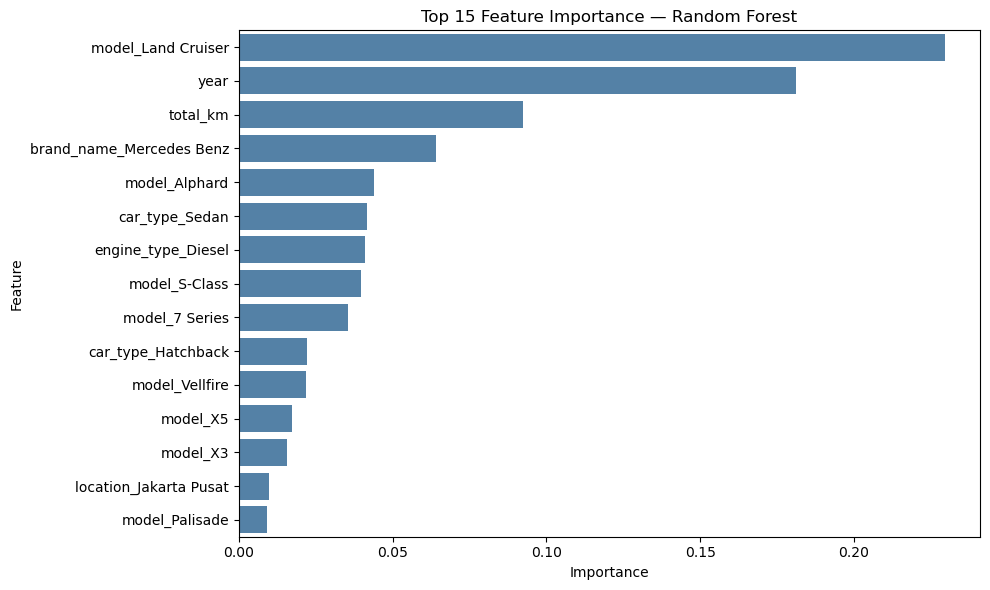

In [83]:
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feat_names  = X_train_enc.columns

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})\
          .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importance — Random Forest')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()
